# **EAS 4860/6860: Tropical Cyclone Risk**

In this Jupyter notebook, you will use soundings to visualize potential intensity. You will need to run this notebook on the EAS student server, where the specialized meteorological libraries (like cartopy, metpy, and eccodes) are already optimized for our use. Please use the "EAS 4860: Tropical Meteorology and Climate" kernel when running this notebook. We will use this throughout the semester. Run the below cell to import the necessary packages.

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

Next, we will assume you have ran the model with some output. Here you want to put in your own file path, where the downscaling model output is stored. Each file represents a synthetic tropical cyclone downscaling of the North Atlantic, from 1970-2024, with 14 tracks per year. We have five 'ensemble member' files, generated by running the model twice. In general, a much larger number of tracks is recommended to do robust statistical analysis on the output.

In [4]:
import glob
fn_list = glob.glob('/share/lin/jlin/era5/downscaling_NA_tuneBetaDrift/*.nc')

Next, we will open the files, using `xarray`, by concatenating along a new dimension, 'ensemble'.

In [5]:
# Open each of the files, by concatenating along a new dimension, 'ensemble'.
ds = xr.open_mfdataset(fn_list, concat_dim='ensemble', combine='nested')

Now, we will have to set some parameters in order to calculate a few quantities, such as the seasonal cycle and interannual frequency. Here, we set the `tracks_per_year` variable, which was the values used in the namelist file when generating the sample data. `tracks_per_year` is the number of tracks to simulate per year.

In [6]:
# Make sure all the variables here in the namelist file are
# consistent with ther values used to generate your data!
tracks_per_year = 14 # equal to namelist.tracks_per_year

First, we will calculate the seasonal cycle. In order to calculate the seasonal cycle for a particular basin, we need to use the 'tc_basins' variable to select for that basin, and use that mask to access the month of the track. The below code does this and plots the seasonal cycle. Note, we only downscaled the North Atlantic here, so you will have to run the model yourself to look at the modeled seasonal cycle for other basins.

(0.5, 12.5)

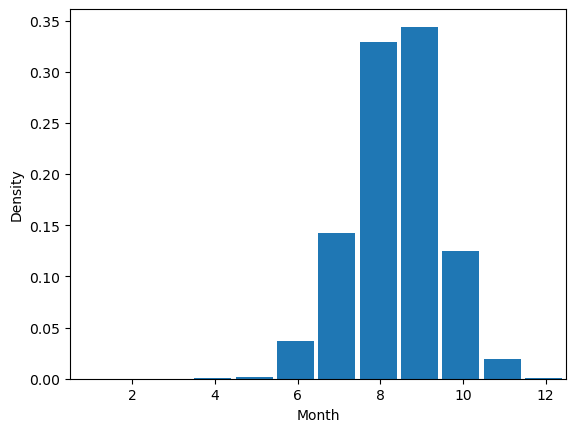

In [7]:
basin_id = 'NA' # see ds['basin'] for a list of basin IDs
mask = ds['tc_basins'] == basin_id
plt.hist(ds['tc_month'].where(mask).load().data.flatten(),
         density = True, bins = np.arange(-0.5, 12.6, 1), width = 0.90)
plt.xlabel('Month'); plt.ylabel('Density')
plt.xlim([0.5, 12.5])

Next, we will calculate the interannual frequency predicted by the model. This is a little trickier, since we need to understand the random seeding process developed by Kerry Emanuel. The model randomly seeds storms every where, and evolves them in space and time. Most of the seeds die out, but a few survive, which are kept as the storms. Let's say that $N_{seeds}$ number of seeds were needed to generate $N_{storms}$ number of storms. Then the 'seed survival rate', $\Gamma$ can be defined as:
$$
    \Gamma = \frac{N_{\text{storms}}}{N_{\text{seeds}}}
$$
which has units storms per seed. Note, in order to convert this into a number of storms (i.e. a frequency), we need to multiply by a singular constant with units seeds. Here is where we assume a *fixed* seeding frequency across all years (see Emanuel 2022 for more nuanced discussion), $c$, with units seeds per year. Then, the frequency of storms per year, $f_{\text{storms}}$ is simply:
$$
    f_{\text{storms}} = c \Gamma
$$

In this model, $N_{\text{storms}}$ is set by the user (`tracks_per_year`), and $N_{\text{seeds}}$ is given by the model. However, $c$ is unknown, and can be thought of as a 'tuning' parameter. Here, we will determine $c$ by simply setting it so that the long term average of $f_{\text{storms}}$ is equal to the observed long-term average. However, we should be clear that the inherent assumptions here are a subject of open research.

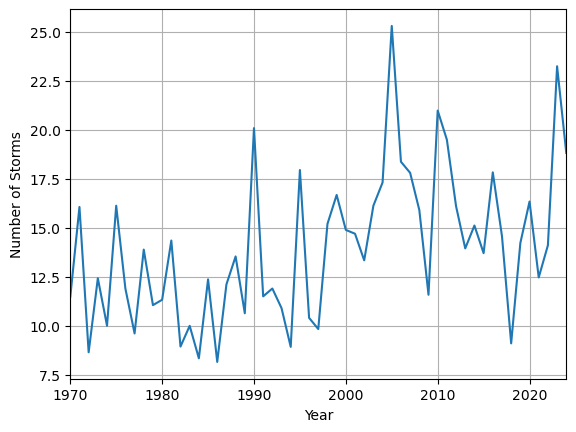

In [8]:
# Total number of seeds, per month, needed to generate a fixed number
# of storms per year, summed across the 'ensemble members' (file).
total_seeds = ds['seeds_per_month'].sum('ensemble')
total_seeds_per_year = ds['seeds_per_month'].sum(['ensemble', 'month'])
total_seeds_per_year_NA = total_seeds_per_year.sel(basin = 'NA')

# Calculate interannual frequency, setting the average frequency
# equal to 'obs_tracks_per_year', by multiplying by a constant.
obs_tracks_per_year = 14    # should be calculated using observations
gamma = tracks_per_year / total_seeds_per_year_NA
c = obs_tracks_per_year / gamma.mean()  # seeding frequency constant
storm_freq = (c * gamma).load()

plt.plot(ds['year'], storm_freq)
plt.xlim([ds['year'][0], ds['year'][-1]])
plt.xlabel('Year'); plt.ylabel('Number of Storms')
plt.grid()

Finally, in this section, we will include some sample analysis on retrieving return period analyses for singular points in space. It is important to remember here that generally, a large number of synthetic tracks are necessary to robustly estimate return period. However, for the purposes of this notebook, we will use just the five provided sample files, so the estimates will *not* be robust. We will use the procedure defined in Lin et al. (2025), which looks at the maximum intensity of all storms that pass within 100-km of a point, which we will choose to be a specific coastal gate (feel free to set this to whatever point you'd like).

In [9]:
# Haversine function, which calculates the great-circle
# distances between two points [lon1, lat1], [lon2, lat2].
def haversine(lon1, lat1, lon2, lat2):
    # Convert decimal degrees to radians
    lon1 = np.deg2rad(lon1)
    lat1 = np.deg2rad(lat1)
    lon2 = np.deg2rad(lon2)
    lat2 = np.deg2rad(lat2)

    # Use the Haversine formula.
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = (np.square(np.sin(dlat/2)) + np.cos(lat1) *
         np.cos(lat2) * np.square(np.sin(dlon/2)))
    c = 2 * np.arcsin(np.sqrt(a))

    r_earth = 6378000   # m
    km = (r_earth / 1000.) * c
    return(km)

# Point of interest longitude/latitude coordinates
# We will read "Gate 28", and take the mid-point as the point of interest.
import pandas as pd
coasts = pd.read_csv('/share/lin/jlin/US_CoastalSegs_50nauticalmile.csv')
idx_coast = 28

clat = (coasts.iloc[idx_coast]['Lat'] + coasts.iloc[idx_coast]['Lat']) / 2
clon = (coasts.iloc[idx_coast]['Lon'] + coasts.iloc[idx_coast]['Lon']) / 2

(1970.0, 2024.0)

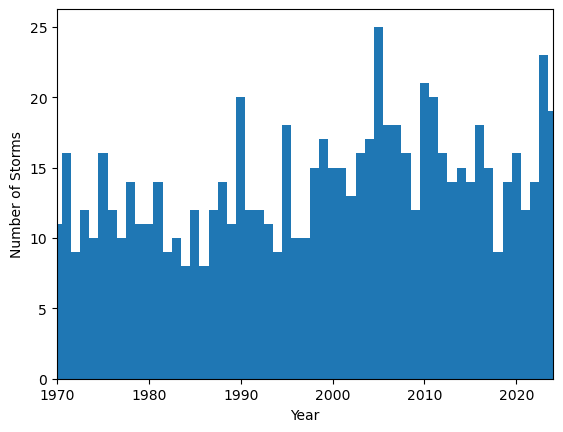

In [ ]:
# Generate a ensemble member representing a counterfactual of historical activity,
# by bootstrapping the entire synthetic dataset while preserving the interannual
# frequency of storms.
# Note: This is different from running random seeding until there
# are a specified total number of storms over the synthetic time period.
ds_bootstrap = []
stacked = ds.stack(track=('ensemble', 'n_trk')).drop_vars(['seeds_per_month'])
idx_trks = 0

# For each year, sample the N storms, where N is the frequency
# of storms in that year, estimated from the random seeding.
for yr in storm_freq['year'].data:
    selected = stacked.sel(track = stacked.tc_years == yr)
    N_storm = int(np.round(float(storm_freq.sel(year = yr))))
    sampled_indices = np.random.choice(len(selected['track']), size=N_storm, replace=False)
    sampled = selected.isel(track=sampled_indices).reset_index('track')
    sampled['track'] = range(idx_trks, idx_trks + N_storm)
    idx_trks += N_storm
    ds_bootstrap.append(sampled)

# 'ensemble' now contains the ensemble member that the track was drawn from,
# and similarly for 'n_trk' (the track number in the ensemble).
# 'track' is a new dimension that contains the new track number.
# At this point, you may want to save each ensemble member to a file
# so you do not have to run the boostrap process again (or repeat it many times).
ds_ens = xr.concat(ds_bootstrap, dim = 'track').load()


# The below figure shows the storm frequency per year.
plt.figure()
plt.hist(ds_ens['tc_years'], bins = np.arange(1969.5, 2024.6, 1))
plt.xlabel('Year'); plt.ylabel('Number of Storms')
plt.xlim([1970, 2024])

Now, we will use the powerful abilities of `xarray` to find the maximum intensity of each storm, when it is within 50-km of the selected point of interest.

In [12]:
r_dist = 50

# Distance of each track from the selected point of interest.
dists = haversine(clon, clat, ds_ens['lon_trks'], ds_ens['lat_trks']).load()

# Find the maximum intensity of each storm, when it is within
# r_dist of the selected point of interest.
vmax_at_poi = ds_ens['vmax_trks'].where(dists <= r_dist).max(dim = 'time').load()

In [ ]:
# Do the same thing, except with ibtracs data
import datetime

fn_ib = '/share/lin/jlin/ibtracs/IBTrACS.ALL.v04r01.nc'
yearS_ib = 1970; yearE_ib = 2024
ds_ib = xr.open_dataset(fn_ib)
dt_ib = np.array([datetime.datetime.utcfromtimestamp(int(x)/1e9) for x in np.array(ds_ib['time'][:, 0])])
dt_isnan = np.isnan(ds_ib['time'].data)
conv_dt = lambda x: datetime.datetime.utcfromtimestamp(int(x)/1e9).replace(second = 0, microsecond=0)
dts_ib = np.full(ds_ib['time'].shape, datetime.datetime(1, 1, 1))
dts_ib[~dt_isnan] = np.vectorize(conv_dt)(ds_ib['time'].data[~dt_isnan])
date_mask = np.logical_and(dt_ib >= datetime.datetime(yearS_ib, 1, 1), dt_ib <= datetime.datetime(yearE_ib+1, 1, 1))
ib_lon = ds_ib['lon'].data
ib_lon[ib_lon < 0] += 360
ib_lat = ds_ib['lat'].load().data
ib_spd = ds_ib['storm_speed'].load()
ib_dir = ds_ib['storm_dir'].load()        
usa_wind = ds_ib['usa_wind'].load()
n_tc_per_year = np.zeros(yearE_ib - yearS_ib + 1)
n_mtc_per_year = np.zeros(yearE_ib - yearS_ib + 1)
gen_lon_hist = np.full(dt_ib.shape, np.nan)
gen_lat_hist = np.full(dt_ib.shape, np.nan)
track_lon_hist = np.full(ib_lon.shape, np.nan)
track_lat_hist = np.full(ib_lon.shape, np.nan)
utrans_hist = np.full(ib_lon.shape, np.nan)
vtrans_hist = np.full(ib_lon.shape, np.nan)
gen_utrans_hist = np.full(dt_ib.shape, np.nan)   
gen_vtrans_hist = np.full(dt_ib.shape, np.nan)
vmax_hist = np.full(ib_lon.shape, np.nan)
basin_hist = ds_ib['basin'].load().data[:, 0].astype('U2')
basin_names = np.array(sorted(np.unique(basin_hist)))
n_tc_per_year_basin = np.zeros((len(basin_names), yearE_ib - yearS_ib + 1))
pdi_per_year_basin = np.zeros((len(basin_names), yearE_ib - yearS_ib + 1))
mpd_per_year_basin = np.zeros((len(basin_names), yearE_ib - yearS_ib + 1))
vmax_tc = np.nanmax(usa_wind, axis = 1)
tc_lmi = np.full(dt_ib.shape, np.nan)
tc_lat_lmi = np.full(dt_ib.shape, np.nan)
for i in range(yearS_ib, yearE_ib + 1, 1):
    mask = ((dt_ib >= datetime.datetime(i, 1, 1)) &
            (dt_ib <= datetime.datetime(i, 12, 31)) &
            (~np.all(np.isnan(usa_wind.data), axis = 1)))
    mask_f = np.argwhere(mask).flatten()

    n_tc_per_year[i - yearS_ib] = np.sum(mask)
    for (b_idx, b_name) in enumerate(basin_names):
        if b_name[0] == 'S':
            b_mask = ((dt_ib >= datetime.datetime(i-1, 6, 1)) &
                    (dt_ib <= datetime.datetime(i, 6, 30)) &
                    (~np.all(np.isnan(usa_wind.data), axis = 1)))                
        else:
            b_mask = ((dt_ib >= datetime.datetime(i, 1, 1)) &
                    (dt_ib <= datetime.datetime(i, 12, 31)) &
                    (~np.all(np.isnan(usa_wind.data), axis = 1)))
        n_tc_per_year_basin[b_idx, i - yearS_ib] = np.sum(b_mask & (vmax_tc >= 34) & (basin_hist == b_name))
        pdi_mask = b_mask & (basin_hist == b_name)
        mpd_per_year_basin[b_idx, i - yearS_ib] = np.sum(np.power(vmax_tc[pdi_mask] / 1.94384, 3))

    # n_mtc_per_year[i - yearS_ib] = np.sum(vmax_tc_yr >= 35)
    vmax_time = usa_wind[mask, :]['time'].load().data
    int_obs = usa_wind[mask, :].data / 1.94384

    for j in range(int(np.sum(mask))):
        if not bool(np.all(np.isnan(usa_wind[mask][j]))):
            lmi_idx = np.nanargmax(usa_wind[mask][j], axis = 0)
            tc_lat_lmi[mask_f[j]] = float(ib_lat[mask][j,lmi_idx])
            tc_lmi[mask_f[j]] = float(usa_wind[mask][j, lmi_idx])
            if tc_lmi[mask_f[j]] >= 35:
                gen_idx = np.nanargmin(np.abs(usa_wind[mask][j, :] - 35), axis = 0)
                gen_lon_hist[mask_f[j]] = ib_lon[mask][j, gen_idx]
                gen_lat_hist[mask_f[j]] = ib_lat[mask][j, gen_idx]
                track_lon_hist[mask_f[j], gen_idx:] = ib_lon[mask][j, gen_idx:]
                track_lat_hist[mask_f[j], gen_idx:] = ib_lat[mask][j, gen_idx:]
                vmax_hist[mask_f[j], gen_idx:] = usa_wind[mask][j, gen_idx:]                
                gen_utrans_hist[mask_f[j]] =  ib_spd[mask][j, gen_idx] * np.sin(np.deg2rad(ib_dir[mask][j, gen_idx])) / 1.94384               
                gen_vtrans_hist[mask_f[j]] =  ib_spd[mask][j, gen_idx] * np.cos(np.deg2rad(ib_dir[mask][j, gen_idx])) / 1.94384
                vtrans_hist[mask_f[j], gen_idx:] = ib_spd[mask][j, gen_idx:] * np.cos(np.deg2rad(ib_dir[mask][j, gen_idx:])) / 1.94384
                utrans_hist[mask_f[j], gen_idx:] = ib_spd[mask][j, gen_idx:] * np.sin(np.deg2rad(ib_dir[mask][j, gen_idx:])) / 1.94384
gen_lon_hist[gen_lon_hist < 0] += 360

# Distance of each historical track from the selected point of interest.
# Find the maximum intensity of each storm, when it is within
# r_dist of the selected point of interest.
dists = haversine(clon, clat, track_lon_hist, track_lat_hist)
vmax_hist_xr = xr.DataArray(vmax_hist / 1.94834, dims = ['time', 'track'], coords = {'track': np.arange(vmax_hist.shape[1])})
dists = xr.DataArray(dists, dims = ['time', 'track'], coords = {'track': np.arange(dists.shape[1])})
vmax_hist_at_poi = vmax_hist_xr.where(dists <= r_dist).max(dim = 'time').load()

Finally, to calculate the return period, notice that the total number of years of tropical cyclone activity we have is 45 times the number of ensemble members, each simulating 45 years of tropical cyclone activity.

In [ ]:
total_years = len(ds['year']) * len(ds['ensemble'])

# Calculate the number of instances where a storm exceeded
vmax_bins = np.arange(10, 81, 5)
exceedance_count = np.zeros(len(vmax_bins))
vmax_at_poi_flat = vmax_at_poi.data.flatten()

for i in range(len(vmax_bins)):
    exceedance_count[i] = np.sum(vmax_at_poi_flat >= vmax_bins[i])

# Plot, on a log y-scale, the return period of the intensity
vmax_bins_knots = vmax_bins*1.94384
return_period = total_years / exceedance_count
return_period_hist = (yearE_ib - yearS_ib + 1) / exceedance_count_hist
plt.plot(vmax_bins_knots, np.log(return_period))
plt.plot(vmax_bins_knots, np.log(return_period_hist))
plt.yticks(np.log(np.array([2, 5, 10, 20, 30, 50, 100, 200])),
           [2, 5, 10, 20, 30, 50, 100, 200])
plt.xlabel('Intensity (knots)')
plt.ylabel('Return Period (years)')
plt.grid()
plt.ylim([np.log(2), np.log(200)])
plt.xlim([50, 150])
plt.title('100-km within Gate 28')
plt.legend(['Synthetic', 'Historical'])

NameError: name 'vmax_hist_at_poi' is not defined

Now, let us go one step further, by estimating the damage from each storm. In reality, the risk is function of the (1) hazard, (2) exposure, and (3) vulnerability. In the previous section, we have a way to model the hazard. However, going from the hazard to the actual loss is much harder, since both exposure and vulnerability are highly localized quantities. We will see an example of the former later. For the purposes of this exercise, we will use the non-dimensional damage function from [Emanuel (2011)](https://journals.ametsoc.org/view/journals/wcas/3/4/wcas-d-11-00007_1.xml#bib27), which is only a function of wind speed. This function is highly idealized and not meant to be used for real-world application, but is rather useful for simple exercises and thought experiments. In reality, damage is much more than just a function of wind hazard. For example, storm surge can lead to colossal damages near coasts. The function `damage_emanuel` returns the non-dimensional damage (the fraction of property value lost) for a given intensity hazard. The non-dimensional damage, $f$ is defined as:
$$
    f = \frac{v_n^3}{1 + v_n^3}
$$
where,
$$
    v_n = \frac{\text{MAX}[V-V_{\text{thresh}}, 0]}{V_{\text{half} - V_{\text{thresh}}}}
$$
Here, $V$ is the wind speed, $V_{\text{thresh}}$ is the wind threshold below which no damage occurs, and $V_{\text{half}}$ is the wind speed at which half of property value is lost. This function can be qualitatively explained as follows. The power dissipation of a hurricane is roughly proportional to:
$$
P = C_d \rho V^3
$$
where $P$ is the rate of energy dissipation per unit time per unit horizontal surface area, $C_d$ is a drag coefficient, $\rho$ is density, and $V$ is wind speed. $P$ can be thought of as roughly proportional to damage, hence the cubic dependence of $f$ on $v_n$. Furthermore, below some wind speed threshold, there is no damage, indicated by $V_{\text{thresh}}$, while above some threshold, there is catastrophic damage.

In [104]:
# Damage function from Emanuel (2011)
# Returns the non-dimensional damage for a given wind speed v_wind (knots).
def damage_emanuel(v_wind, v_thresh = 50, v_half = 160):
    # v_thresh and v_half are intended to be be used in knots
    vn = np.maximum(v_wind - v_thresh, 0) / (v_half - v_thresh)
    dmg = np.power(vn, 3) / (1 + np.power(vn, 3))
    return dmg

Plot the damage as a function of the wind speed, using the code below. Feel free to vary the parameters, `v_thresh`, and `v_half`, to understand the dependence on those two parameters.

(0.0, 1.0)

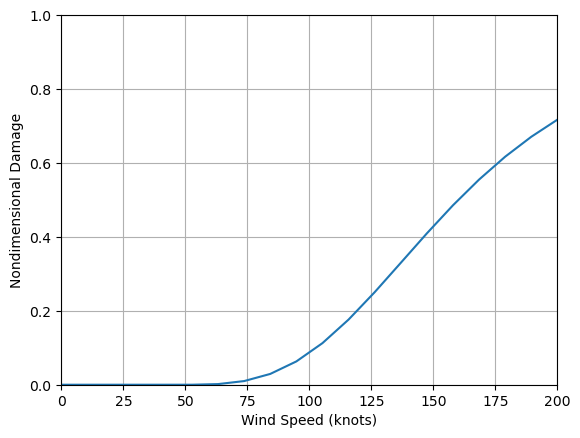

In [105]:
v_wind = np.linspace(0, 200, 20)    # wind speed
plt.plot(v_wind, damage_emanuel(v_wind))
plt.grid(); plt.ylabel('Nondimensional Damage');
plt.xlabel('Wind Speed (knots)')
plt.xlim([0, v_wind[-1]])
plt.ylim([0, 1])

Now, let us convert the hazard curves to non-dimensional damage curves. Again, feel free to vary the parameters, `v_thresh`, and `v_half`, to understand the dependence of the non-dimensional damage return period curves on those two parameters.

(0.0, 0.5)

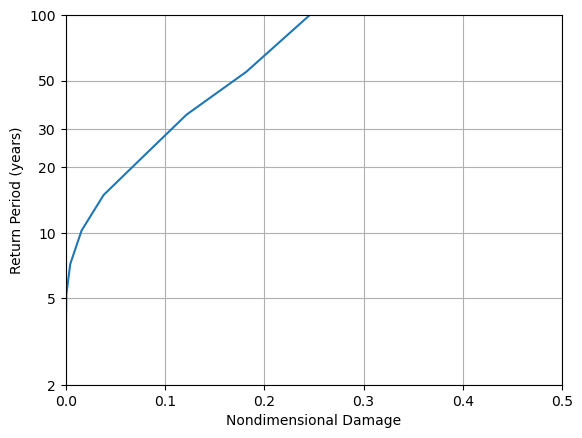

In [106]:
plt.plot(damage_emanuel(vmax_bins_knots), np.log(return_period))
plt.yticks(np.log(np.array([2, 5, 10, 20, 30, 50, 100])),
           [2, 5, 10, 20, 30, 50, 100])
plt.xlabel('Nondimensional Damage')
plt.ylabel('Return Period (years)')
plt.grid()
plt.ylim([np.log(2), np.log(100)])
plt.xlim([0, 0.5])

Of course, these estimates are totally useless without some measure of the underlying exposure. Asset exposure data is hard to access, especially in the U.S., since home insurance is privatized. To this end, we will use the asset exposure dataset of [Eberenz et al. (2020)](https://essd.copernicus.org/articles/12/817/2020/), which uses both nightlight intensity and geographical population data to estimate asset exposure. It is important to remember that these are estimates, and not actual property value data. The asset exposure data is quite large in size, and thus we provide the exposure data for the state of Florida. Use the below code to read the data, and plot it on a map. What do you notice about the spatial dependence of the exposure?

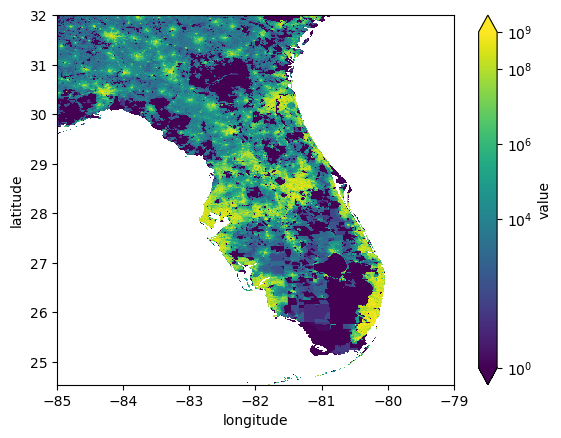

In [107]:
# Read in the exposure dataset
ds_exposure = xr.open_dataset('data/fl_exposure_litpopv1_2.nc')['value']

# Plot exposure values in terms of log base 10.
cax = np.log10(ds_exposure).plot.pcolormesh(vmin = 0, vmax = 9)
cbar = cax.colorbar
cbar_ticks = [0, 4, 6, 8, 9]
cbar.set_ticks(cbar_ticks)  # Set tick positions
cbar.set_ticklabels([r'$10^{%d}$' % x for x in cbar_ticks])

Finally, we will try to convert the non-dimensional damage to actual dollar amount damage, using the exposure dataset. For the purposes of this exercise, we will simply consider the total storm loss to be the damage to the property values within 100-km of the point of interest.  This is shown in the below code, where the red outline shows all points within 100-km of the point of interest. The total asset value will also be printed.

Total Assets: $1088785343198.977295


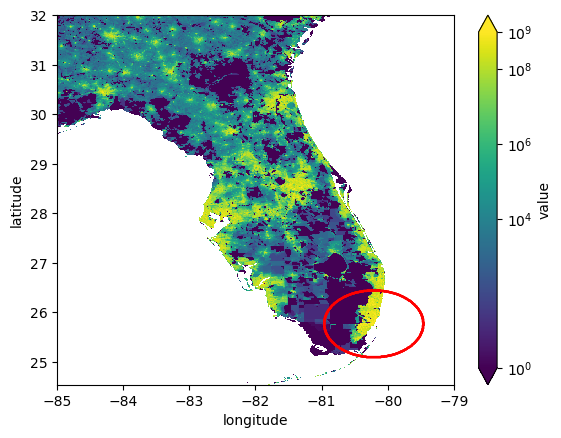

In [108]:
# Distance of each track from the selected point of interest.
dists_poi = haversine(clon, clat, 
                      ds_exposure['longitude'], 
                      ds_exposure['latitude']).load()

# Plot exposure values in terms of log base 10.
cax = np.log10(ds_exposure).plot.pcolormesh(vmin = 0, vmax = 9)
(dists_poi <= r_dist).plot.contour(colors = 'r')
cbar = cax.colorbar
cbar_ticks = [0, 4, 6, 8, 9]
cbar.set_ticks(cbar_ticks)  # Set tick positions
cbar.set_ticklabels([r'$10^{%d}$' % x for x in cbar_ticks])

exp_poi = ds_exposure.where(dists_poi <= r_dist, drop = True)
print('Total Assets: $%f' % float(exp_poi.sum()))

To estimate the total loss per storm, we will multiply the value of the non-dimensional damage at each grid point, and sum over all points within 100-km of the point of interest. In the real world, the hazard is also spatially dependent (more losses expected on the coasts), and should be taken into account for more robust loss estimate modeling. We will forgo that for simplicity here.

In [109]:
exposure_map = exp_poi.expand_dims({'v': len(vmax_bins_knots)})
f_emanuel = damage_emanuel(vmax_bins_knots)
dmg_hazard = xr.DataArray(data = f_emanuel, dims = 'v')

# Sum over all points within 100-km of the point of interest
total_loss_per_v = (exposure_map*dmg_hazard).sum(['longitude', 'latitude'])+1

Finally, plot the return period curve of total expected loss. Where do you observe the curve to be steepest?

(9.0, 12.0)

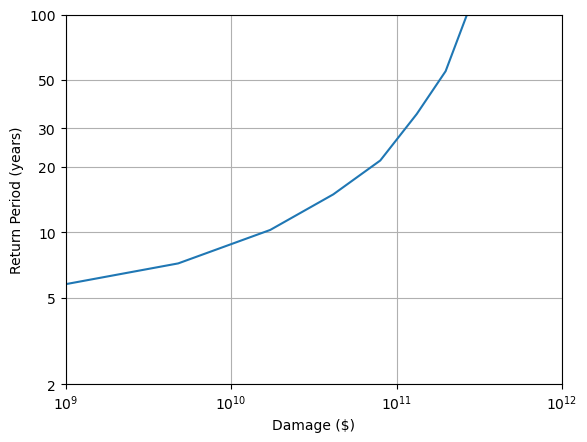

In [110]:
plt.plot(np.log10(total_loss_per_v), np.log(return_period))
plt.yticks(np.log(np.array([2, 5, 10, 20, 30, 50, 100])),
           [2, 5, 10, 20, 30, 50, 100])
x_labs = np.arange(9, 12.01, 1)
plt.xticks(x_labs, [r'$10^{%d}$' % x for x in x_labs])
plt.xlabel('Damage ($)')
plt.ylabel('Return Period (years)')
plt.grid()
plt.ylim([np.log(2), np.log(100)])
plt.xlim([9, 12])

To go one step further, let us look at the distribution of annual loss at the point of interest. This should give us an idea of the voltatility of loss events per year. The below piece of code does this by selecting all storms from a particular year, only including storms within 100-km of the point of interest, and calculating the annual loss for all ensemble members. In the rare event that there are two loss events in a single year, we add the loss for each storm together.

In [ ]:
# Since there are a fixed number of storms per year in the Atlantic, 
# we are not taking into account interannual storm frequency into our
# estimates of the annual loss volatility.
total_loss_per_year = np.zeros((len(ds['year']), len(ds['ensemble'])))
for i in range(len(ds['year'])):
    yr_map = (ds['tc_years'] == ds['year'][i]).compute()
    vmax_annual_knots = vmax_at_poi.where(yr_map, drop = True)*1.94384
    damage_annual = damage_emanuel(vmax_annual_knots)

    # Sum over all storms and all points within 100-km of the POI.
    # Add 1/freq to define no loss events as 10^0.
    yr_freq = int(float(storm_freq.isel(year = i)))
    total_loss_per_storm = (exp_poi * damage_annual).sum(['longitude', 'latitude']) + 1. / yr_freq  

    # Bootstrap the existing data to account for interannual storm frequency
    for j in range(len(ds['ensemble'])):
        total_loss_per_year[i,j] = np.sum(np.random.choice(total_loss_per_storm.data.flatten(), size=yr_freq, replace=False))
    #total_loss_per_year[i, :] = total_loss_per_storm.sum('n_trk')

In [ ]:
yr_freq = int(float(storm_freq.isel(year = i)))


array([0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857,
       0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857,
       0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857,
       0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857,
       0.07142857, 0.07142857, 0.07142857, 0.07142857])

In [150]:
        np.sum(np.random.choice(total_loss_per_storm.data.flatten(), size=yr_freq, replace=False))

1.7142857142857142

In [151]:
np.sum(np.random.choice(total_loss_per_storm.data.flatten(), size=yr_freq, replace=False))

1.7142857142857142

Finally, let's plot the distribution of annual loss from storms impacting the location of interest. What does the distribution look like? What is the annual expected loss?

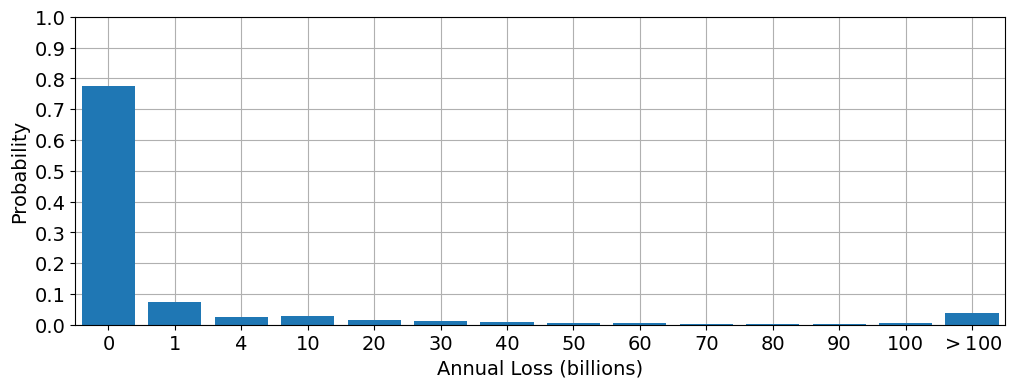

In [129]:
# Years of no hurricane damage will be centered at 0.
#dmg_bins = np.hstack([np.array([-2, 2, 1e9, 5e9, 10e9, 50e9]), np.arange(20e9, 251e9, 10e9)])
dmg_bins = np.array([-2, 2, 2e9, 6e9, 15e9, 25e9, 35e9, 45e9, 55e9, 65e9, 75e9, 85e9, 95e9, 105e9, 1e12])
dmg_cbins = np.round(((dmg_bins[1:] + dmg_bins[0:-1]) / 2) / 1e6) * 1e6

H = np.histogram(total_loss_per_year.flatten(), bins = dmg_bins)

plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(12, 4))
plt.bar(range(len(dmg_bins)-1), (H[0] / len(total_loss_per_year.flatten())))
x_str = [str(int(x)) for x in (dmg_cbins / 1e9)]
x_str[-1] = r'$> 100$'
plt.xticks(range(len(dmg_bins)-1), x_str)
plt.ylabel('Probability'); plt.xlabel('Annual Loss (billions)');
plt.grid(); plt.gca().set_axisbelow(True)
plt.xlim([-0.5, len(dmg_cbins)-0.5])
plt.ylim([0, 1]); plt.yticks(np.arange(0, 1.01, 0.1));
#plt.ylim([1e-5, 1])
#plt.yticks([-3, -2, -1, 0], [r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', r'$10^0$'])

(array([4.247e+03, 1.060e+02, 4.700e+01, 3.200e+01, 2.500e+01, 1.700e+01,
        1.200e+01, 7.000e+00, 3.000e+00, 4.000e+00]),
 array([1.00000000e+00, 5.88737955e+10, 1.17747591e+11, 1.76621387e+11,
        2.35495182e+11, 2.94368978e+11, 3.53242773e+11, 4.12116569e+11,
        4.70990364e+11, 5.29864160e+11, 5.88737955e+11]),
 <BarContainer object of 10 artists>)

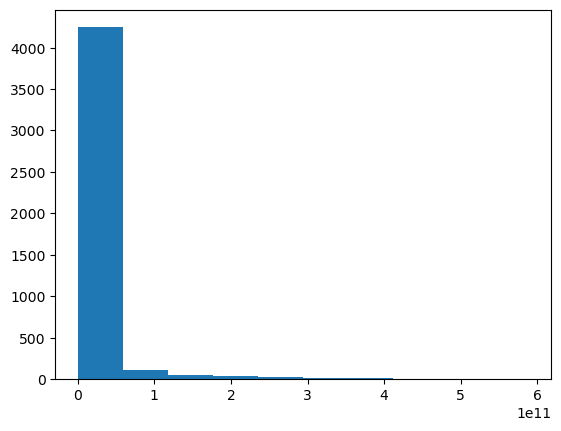

In [113]:
plt.hist(total_loss_per_year.flatten())

**Bonus Exercise**: How does the annual loss volatility change if you include interannual variability in storm frequency?